## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, log_loss, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from xgboost import XGBClassifier

## Training

A single pool is generated once, then sliced by class into disjoint subsets: one for the training set (50:50) and several for the test sets (one per repeat x imbalance ratio, used for error bars). 

Slicing from one pool, rather than calling `make_classification` again per test set, keeps every slice drawn from the same underlying concept, since a fresh call with the same `random_state` but different `n_samples`/`weights` shifts the cluster centroids. 

Models are trained once, outside the loop.

In [2]:
random_state = 42
train_per_class = 1000
minority_test_samples = 200
imbalance_ratios = [10, 100, 500, 1000, 5000]
n_repeats = 3  # test-set draws per imbalance ratio, for error bars

dataset_params = dict(
    n_features=20, n_informative=10, n_redundant=5, n_repeated=0,
    n_classes=2, flip_y=0, class_sep=0.7,
)

classifiers = {
    "XGBoost": XGBClassifier(random_state=random_state, n_jobs=-1),
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000, random_state=random_state)),
    ]),
}

metrics = ["roc_auc", "average_precision", "log_loss"]
results = {
    name: {ir: {metric: [] for metric in metrics} for ir in imbalance_ratios}
    for name in classifiers
}

# Pool sized to cover the train set plus every (repeat, IR) test set, with a
# small buffer since make_classification's internal rounding can land 1 short.
majority_needed = train_per_class + n_repeats * sum(
    minority_test_samples * ir for ir in imbalance_ratios
)
minority_needed = train_per_class + n_repeats * minority_test_samples * len(imbalance_ratios)
buffer = 10
total_samples = majority_needed + minority_needed + buffer

X, y = make_classification(
    n_samples=total_samples,
    weights=[
        majority_needed / (majority_needed + minority_needed),
        minority_needed / (majority_needed + minority_needed),
    ],
    random_state=random_state,
    **dataset_params,
)
X0, X1 = X[y == 0], X[y == 1]
i0 = i1 = train_per_class

# only training in 2000 samples, 1000 from each class
X_train = np.vstack([X0[:train_per_class], X1[:train_per_class]])
y_train = np.concatenate([np.zeros(train_per_class), np.ones(train_per_class)])
trained_models = {name: clf.fit(X_train, y_train) for name, clf in classifiers.items()}

for repeat in range(n_repeats):
    for ir in imbalance_ratios:
        n_majority = minority_test_samples * ir

        # testing on naive data
        X_test = np.vstack([X0[i0:i0 + n_majority], X1[i1:i1 + minority_test_samples]])
        y_test = np.concatenate([np.zeros(n_majority), np.ones(minority_test_samples)])
        i0 += n_majority
        i1 += minority_test_samples

        for name, model in trained_models.items():
            y_proba = model.predict_proba(X_test)[:, 1]
            results[name][ir]["roc_auc"].append(roc_auc_score(y_test, y_proba))
            results[name][ir]["average_precision"].append(average_precision_score(y_test, y_proba))
            results[name][ir]["log_loss"].append(log_loss(y_test, y_proba, labels=[0, 1]))

## Prepare results

In [3]:
stats = {
    name: {metric: {"mean": [], "std": []} for metric in metrics}
    for name in classifiers
}

for name in classifiers:
    for ir in imbalance_ratios:
        for metric in metrics:
            vals = np.array(results[name][ir][metric])
            stats[name][metric]["mean"].append(vals.mean())
            stats[name][metric]["std"].append(vals.std())

In [4]:
def plot_metric(metric, ylabel, title):
    marker_cycle = ["o", "s"]
    fig, ax = plt.subplots(figsize=(7, 5))

    for name, marker in zip(classifiers, marker_cycle):
        clf_stats = stats[name]
        means = np.array(clf_stats[metric]["mean"])
        stds = np.array(clf_stats[metric]["std"])
        line, = ax.plot(imbalance_ratios, means, marker=marker, label=name)
        ax.fill_between(
            imbalance_ratios, means - stds, means + stds,
            alpha=0.2, color=line.get_color(),
        )

    ax.set_xscale("log")
    ax.set_xticks(imbalance_ratios)
    ax.set_xticklabels(imbalance_ratios)
    ax.set_xlabel("Test set imbalance ratio (Majority : Minority)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

## Plot ROC-AUC

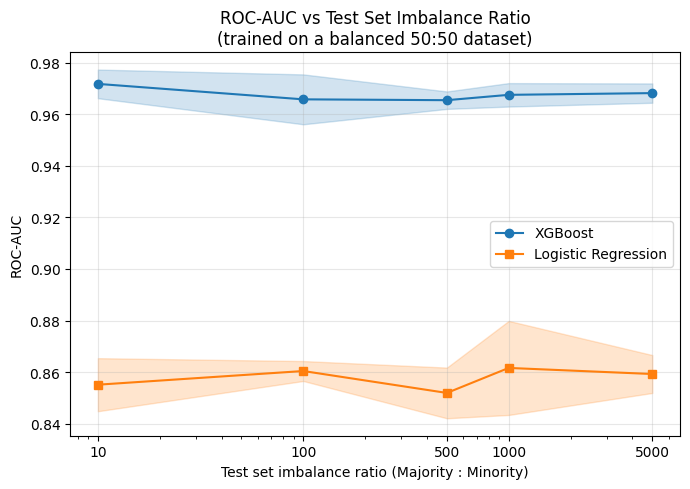

In [5]:
plot_metric("roc_auc", "ROC-AUC", "ROC-AUC vs Test Set Imbalance Ratio\n(trained on a balanced 50:50 dataset)")

## Plot Average Precision

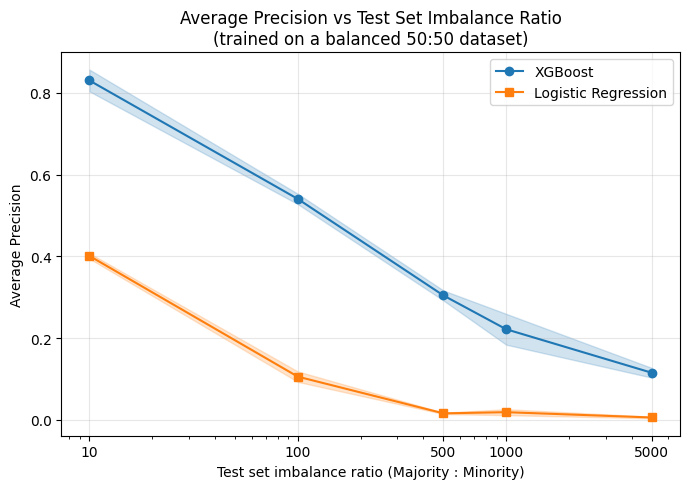

In [6]:
plot_metric("average_precision", "Average Precision", "Average Precision vs Test Set Imbalance Ratio\n(trained on a balanced 50:50 dataset)")

## Plot Log Loss

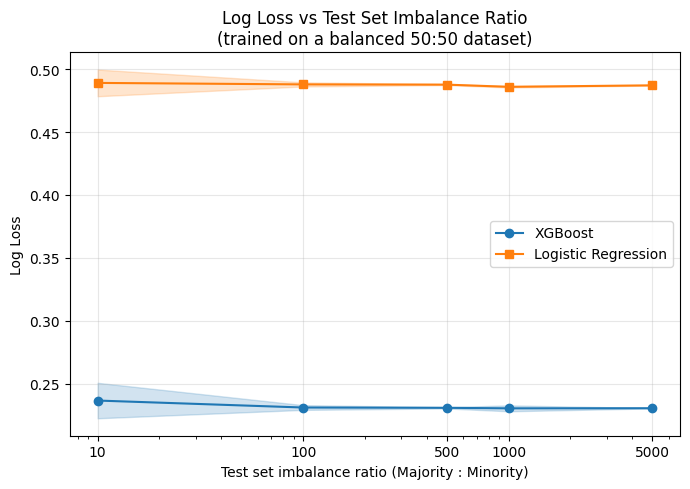

In [7]:
plot_metric("log_loss", "Log Loss", "Log Loss vs Test Set Imbalance Ratio\n(trained on a balanced 50:50 dataset)")